# Load in the libs
### The function calls are all the same it is just the library that changes hence you only change the import library line

In [ ]:
# Python Libs
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('dark_background')

# import pwi_inst.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject as slmlib
# import pwi_inst.hardware.SLM.MeadowlarkBlinkOverDrivePlus.MeadowlarkBlinkOneDrivePlusObject as slmlib
import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass
import pwi_inst.hardware.SLM.SLM_ServerLinux as SLM_Serverlib
# import pwi_inst.hardware.SLM.SLM_Client as SLM_Clientlib
import pwi_inst.hardware.SLM.SLM_ViewerLinux as SLM_Viewerlib
import pwi_inst.utils.camera_utils as cam_utils

# import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
# import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass

In [2]:
import pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey as CamLib


In [3]:
%load_ext autoreload
%aimport pwi_inst.hardware.SLM.SLM_ServerLinux 
%aimport pwi_inst.hardware.SLM.SLM_ViewerLinux
%aimport pwi_inst.hardware.SLM.PhaseMaskClass
%autoreload 1


In [54]:
del slmobj_client

In [72]:


slmobj_client = SLM_Serverlib.SLMLinuxClient(
    client_id="linux_client",
    windows_host="10.196.0.67",
    windows_port=5555,
)
# phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)


slm_linux_linux_client.im.shm will be overwritten
[Linux SLM Client] client_id = linux_client
[Linux SLM Client] stream_name = slm_linux_linux_client
[Linux SLM Client] image_shape = (1024, 1024, 1)


# Example of using the phase mask object that opens up more user friendly abilities


In [73]:
phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)



        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


In [74]:
slmobj_client.GetSLMTemperature()

75.11723795083041

# Launch camera

In [8]:
import pwi_inst.hardware.Cameras.Camera_Client as CamClientlib


In [ ]:
Camobject=CamClientlib.CameraClient(
        host="127.0.0.1",
        port=50731,
        timeout_ms=5000,
        client_id="camera_client")
# Camobject = CamLib.CameraObject(CameraIdx=0,verbose=True)
# Camobject.SetSoftwareTriggerMode()

True


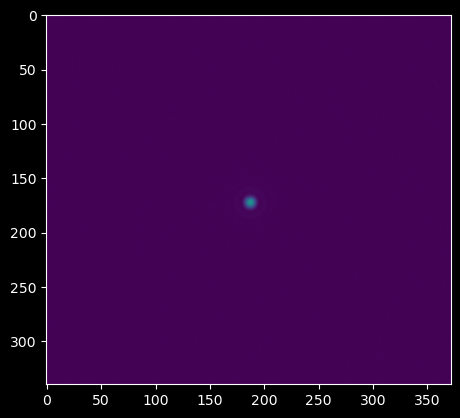

In [18]:
check=bool(slmobj_client.WriteImageToSLM(np.zeros((1024,1024),dtype=np.uint8)))
print(check)
frame_NoStrip=Camobject.GetFrame()
plt.imshow(frame_NoStrip)

True


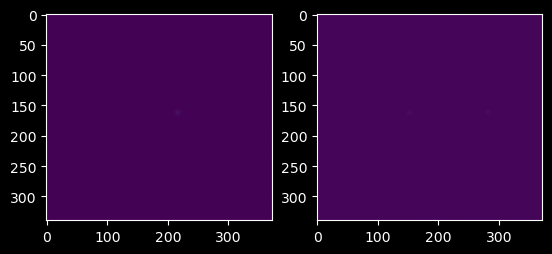

In [89]:
slmobj_client.SetRefreshRate(100e-3)
# phasemaskobj.LCOS_Clean()
check=bool(slmobj_client.WriteImageToSLM(np.zeros((1024,1024),dtype=np.uint8)))
frame_NoStrip=Camobject.GetFrame()
MaskCMPLX=slm_masks.binary_stripe_phase(Nx=1024,Ny=1024,stripe_width=12,phase_value=np.pi/3,orientation="vertical")
MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
check=bool(slmobj_client.WriteImageToSLM(MaskInt))

print(check)
frame_Strip=Camobject.GetFrame()
plt.subplot(1,2,1)
plt.imshow(frame_NoStrip)
plt.subplot(1,2,2)
plt.imshow(frame_Strip)

# Open a viewer to see what you are putting on the slm

In [14]:
viewer = SLM_Viewerlib.SLMLinuxViewer(stream_name=slmobj_client.stream_name,zoom=0.2,fps=30)
viewer.startProcess()
time.sleep(1)
print(viewer.Process.is_alive())

SLM viewer process started with PID 66448


QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vi

True


In [ ]:
viewer.set_zoom(0.2)

In [51]:
viewer.stopProcess()

# Make some full screen displays and load them on to the SLM while changeing the refresh rate

In [ ]:

slmtemp=slmobj_client.GetSLMTemperature()
print("slm temperature:", slmtemp)
for i in range(10000):
    # make simple sprial mask that is the size of the display
    MaskCMPLX=slm_masks.SpiralMask(SpiralNum=i,Nx=slmobj_client.monitor_width,Ny=slmobj_client.monitor_height,pixelSize=17e-6, PlotMasks=False)
    MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
    # MaskInt=np.angle(MaskCMPLX[0,0,:,:]).astype(np.uint8)
    # plt.imshow(MaskInt)
    # change the refresh rate and write the mask to the SLM
    slmobj_client.SetRefreshRate(10e-3)
    #Write the mask to the SLM
    check=bool(slmobj_client.WriteImageToSLM(MaskInt))
    # print(check)


In [57]:
slmobj_client.SetRefreshRate(35e-3)

0.035

# Jitter testing

=== Write Time ===
Mean:   47.113 ms
Std:    0.424 ms
Min:    46.011 ms
Max:    50.671 ms
Jitter: 4.660 ms

=== Loop Interval ===
Mean:   47.194 ms
Std:    0.429 ms
Min:    46.091 ms
Max:    50.749 ms
Jitter: 4.659 ms


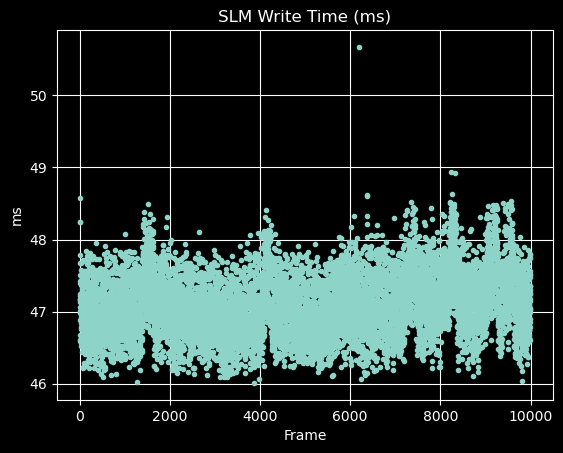

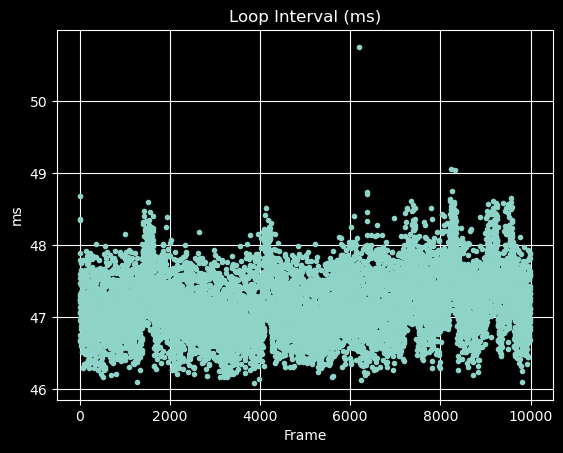

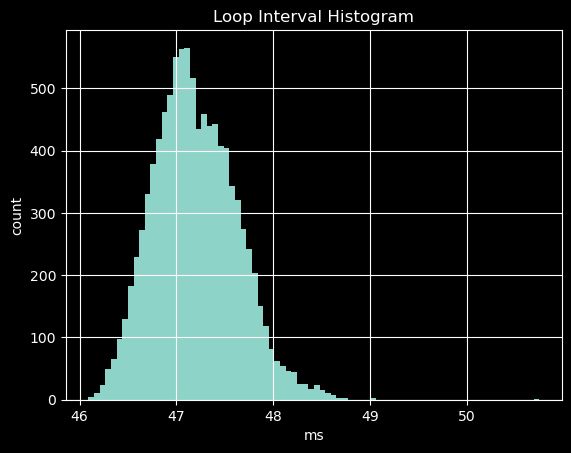

In [60]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

n_frames = 10000

write_times = np.empty(n_frames, dtype=np.float64)
loop_intervals = np.empty(n_frames - 1, dtype=np.float64)

img = np.zeros(
    (slmobj_client.monitor_height, slmobj_client.monitor_width),
    dtype=np.uint8,
)

gc.disable()

last_t = None

try:
    for i in range(n_frames):
        # no allocation, no random generation
        img.fill(i % 255)

        t0 = time.perf_counter()

        if last_t is not None:
            loop_intervals[i - 1] = t0 - last_t

        slmobj_client.WriteImageToSLM(img, channelIdx=0)

        t1 = time.perf_counter()

        write_times[i] = t1 - t0
        last_t = t0

finally:
    gc.enable()

print("=== Write Time ===")
print(f"Mean:   {np.mean(write_times)*1e3:.3f} ms")
print(f"Std:    {np.std(write_times)*1e3:.3f} ms")
print(f"Min:    {np.min(write_times)*1e3:.3f} ms")
print(f"Max:    {np.max(write_times)*1e3:.3f} ms")
print(f"Jitter: {(np.max(write_times)-np.min(write_times))*1e3:.3f} ms")

print("\n=== Loop Interval ===")
print(f"Mean:   {np.mean(loop_intervals)*1e3:.3f} ms")
print(f"Std:    {np.std(loop_intervals)*1e3:.3f} ms")
print(f"Min:    {np.min(loop_intervals)*1e3:.3f} ms")
print(f"Max:    {np.max(loop_intervals)*1e3:.3f} ms")
print(f"Jitter: {(np.max(loop_intervals)-np.min(loop_intervals))*1e3:.3f} ms")

plt.figure()
plt.plot(write_times * 1e3, ".")
plt.title("SLM Write Time (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.plot(loop_intervals * 1e3, ".")
plt.title("Loop Interval (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.hist(loop_intervals * 1e3, bins=80)
plt.title("Loop Interval Histogram")
plt.xlabel("ms")
plt.ylabel("count")
plt.grid()
plt.show()

# actual slm speed test

In [90]:
Camobject.SetExposureTime(1)

0.9946227073669434

In [35]:
def slmRefreshRateCalibration(slmobj_client:SLM_Serverlib.SLMLinuxClient, phasemaskobj:PhaseMaskClass.PhaseMaskObject,Cam:CamClientlib.CameraClient,channel="Red",
                              refreshCount=10,refreshRateMin=0,refreshRateMax=100,MeasCount=1,
                               Direction="vertical", imask=0,pol="H",backgroundLevel=0,strip_value=0.0,
                                       strip_width=10,
                                       ixCamCenter=None,iyCamCenter=None,
                                    x_half_width=None,
                                    y_half_width=None):
    
    mask_NoStrip_MASKTODisplay_256=np.zeros((1024,1024),dtype=np.uint8)
    MaskCMPLX=slm_masks.binary_stripe_phase(Nx=1024,Ny=1024,stripe_width=strip_width,phase_value=strip_value,orientation=Direction)
    mask_Strip_MASKTODisplay_256=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
    
    
    # plt.subplot(1,2,1)
    # plt.imshow(frame_NoStrip)
    # plt.subplot(1,2,2)
    # plt.imshow(frame_Strip)
    refreshArr = np.linspace(refreshRateMin,refreshRateMax,refreshCount)*1e-3
    metricValues=np.zeros((MeasCount,refreshCount))
    intialpwrTracker=np.zeros((MeasCount,refreshCount))
    timetotal_slm=0
    timetotal_cam=0
    
    
    for imeas in range(MeasCount):
        slmobj_client.SetRefreshRate(100.0e-3)
        # MASKTODisplay_256=slm.Draw_Single_Mask( x_center, y_center, mask_NoStrip,backgroundLevel)
        slmobj_client.WriteImageToSLM(mask_NoStrip_MASKTODisplay_256)
        frame_blankslm=Cam.GetFrame() 
        initalpwr= cam_utils.get_relative_power(frame=frame_blankslm,centre=[ixCamCenter,iyCamCenter],x_half_width=x_half_width,y_half_width=y_half_width)
        
        slmobj_client.WriteImageToSLM(mask_Strip_MASKTODisplay_256)
        frame_stripslm=Cam.GetFrame() 
        initalpwr_strip= cam_utils.get_relative_power(frame=frame_stripslm,centre=[ixCamCenter,iyCamCenter],x_half_width=x_half_width,y_half_width=y_half_width)
        # plt.subplot(1,2,1)
        # plt.imshow(frame_blankslm)
        # plt.subplot(1,2,2)
        # plt.imshow(frame_stripslm)
        
        print("Initial Power: "+str(initalpwr_strip/initalpwr ))
        
        for irefreshrate in range(refreshCount):
            slmobj_client.SetRefreshRate(refreshArr[irefreshrate])
            # Draw a strip profile on the SLM and get a frame
            slmobj_client.WriteImageToSLM(mask_Strip_MASKTODisplay_256)
            frame_slmPIStrip=Cam.GetFrame() 
            pwrAfterTilt=cam_utils.get_relative_power(frame=frame_slmPIStrip,centre=[ixCamCenter,iyCamCenter],x_half_width=x_half_width,y_half_width=y_half_width)
            # Draw a Blank profile on the SLM and get a frame
            slmobj_client.WriteImageToSLM(mask_NoStrip_MASKTODisplay_256,channel)
            frame_Reblankslm=Cam.GetFrame() 
            pwrAfterReflat=cam_utils.get_relative_power(frame=frame_Reblankslm,centre=[ixCamCenter,iyCamCenter],x_half_width=x_half_width,y_half_width=y_half_width)
            
            metricValues[imeas,irefreshrate]=pwrAfterTilt/initalpwr
            intialpwrTracker[imeas,irefreshrate]=pwrAfterReflat/initalpwr
            if imeas==0:
                print(metricValues[imeas,irefreshrate])
        if imeas==0:
            plt.plot(refreshArr*1e3,metricValues[imeas,:])
            
            print(metricValues[imeas,irefreshrate])
            
    print(timetotal_slm/MeasCount)
    print(timetotal_cam/MeasCount)
        # print(imeas) 
    return refreshArr,metricValues,intialpwrTracker


Initial Power: 68.68683274021352
71.42704626334519
69.31316725978648
70.1067615658363
1.6619217081850535
67.91459074733096
-0.5409252669039146
-0.03914590747330961
7.01779359430605
1.3487544483985765
0.0498220640569395
1.8256227758007118
-0.701067615658363
0.44483985765124556
1.302491103202847
0.9928825622775801
0.41637010676156583
2.1494661921708187
0.8540925266903915
0.5765124555160143
0.4092526690391459
1.2597864768683273
0.8327402135231317
1.9822064056939501
-0.1494661921708185
0.4626334519572954
0.18149466192170818
2.5587188612099645
0.6370106761565836
70.51957295373666
69.88612099644128
-0.5480427046263345
69.96797153024912
69.90391459074733
0.697508896797153
65.59786476868328
71.32384341637011
71.0711743772242
71.16370106761566
0.4306049822064057
73.12811387900356
70.1067615658363
70.65124555160142
68.74733096085409
71.2170818505338
68.26334519572954
69.34163701067615
66.7829181494662
71.75800711743773
71.2135231316726
70.54804270462634
71.45907473309609
71.5017793594306
72.4234

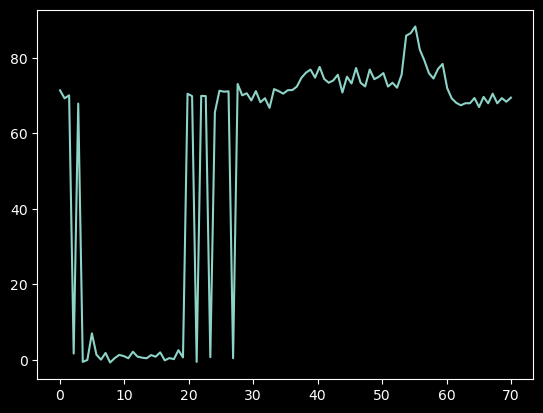

In [81]:
refreshArr,metricValues,intialpwrTracker=slmRefreshRateCalibration(slmobj_client, phasemaskobj,Camobject,channel="Red",
                              refreshCount=100,refreshRateMin=0,refreshRateMax=70,MeasCount=10,
                               Direction="vertical", imask=0,pol="H",backgroundLevel=0,strip_value=np.pi/3,
                                       strip_width=12,
                                       ixCamCenter=148,iyCamCenter=159,
                                    x_half_width=17,
                                    y_half_width=17)

In [85]:
frame_Reblankslm=Camobject.GetFrame() 
pwrAfterReflat=cam_utils.get_relative_power(frame=frame_Reblankslm,centre=[148,159],x_half_width=17,y_half_width=17)
            

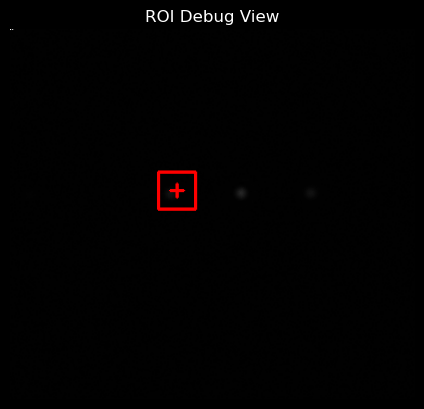

In [87]:
cam_utils.show_aperture(frame=frame_Reblankslm,centre=[148,153],x_half_width=17,y_half_width=17)

In [43]:
refreshArr.shape

(100,)

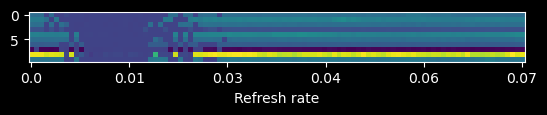

In [82]:

plt.imshow(metricValues)

# choose some tick positions (indices)
x_idx = np.linspace(0, metricValues.shape[1]-1, 6)

# map those indices to your real values
x_labels = np.linspace(refreshArr.min(), refreshArr.max(), 6)

plt.xticks(x_idx, np.round(x_labels, 2))

plt.xlabel("Refresh rate")
plt.show()
# plt.imshow(metricValues,extent=[0,50,refreshArr.min(),refreshArr.max()])

